In [1]:
import os, sys
project_root = os.path.abspath('..').replace('\\', '/')
if project_root not in [p.replace('\\', '/') for p in sys.path]:
    sys.path.append(project_root)

# 07 可视化模块 (core.viz)

提供评分卡开发过程中常用的可视化功能。

**数据说明**: 基于 `hscredit_yyp.xlsx`

In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from hscredit import init_setting
from hscredit.core import viz

init_setting()

# 加载数据
_roots = [Path.cwd(), Path.cwd() / 'examples', Path.cwd().parent]
_fp = None
for _r in _roots:
    for _n in ('hscredit_yyp.xlsx', 'hengshucredit_yyp.xlsx'):
        if (_r / _n).is_file():
            _fp = _r / _n
            break
    if _fp is not None:
        break
if _fp is None:
    raise FileNotFoundError('请将 hscredit_yyp.xlsx 放在 examples/')

df = pd.read_excel(_fp)

# 构造目标变量
df['target'] = (df['MOB1'] > 3).astype(int)

# 准备预测概率（使用中智小牛分C3归一化）
df['score'] = df['中智小牛分C3'].fillna(df['中智小牛分C3'].median())
df['prob'] = (df['score'] - df['score'].min()) / (df['score'].max() - df['score'].min())

print(f"样本数: {len(df):,}")
print(f"坏样本率: {df['target'].mean():.2%}")

样本数: 970
坏样本率: 16.70%


## 1. 分箱图

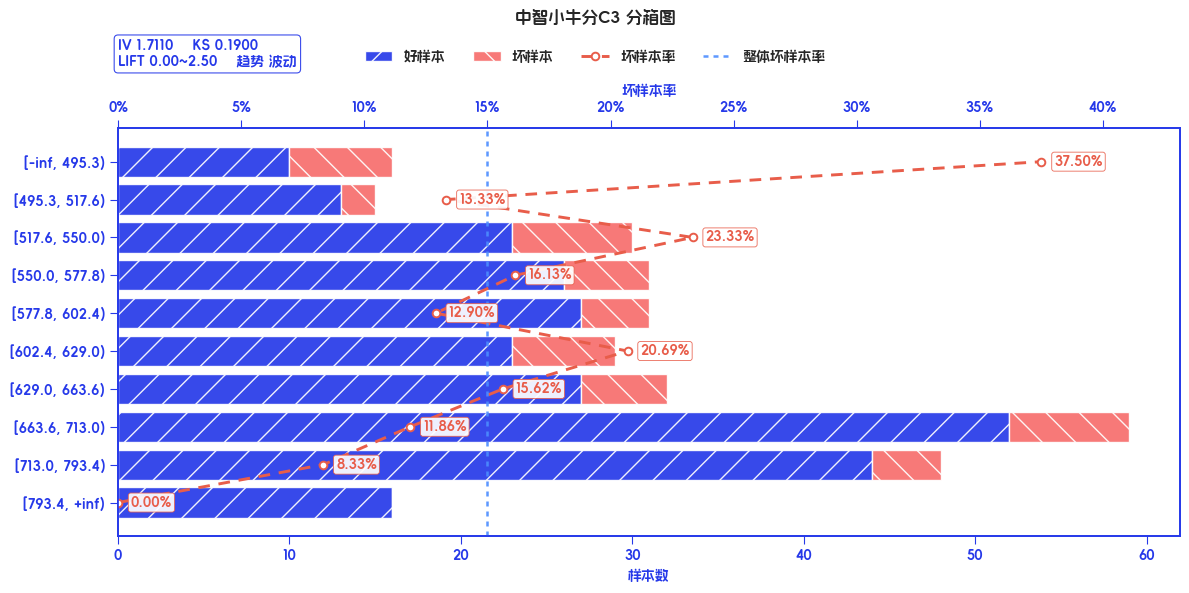

In [3]:
# 分箱图
fig = viz.bin_plot(
    df,
    feature='中智小牛分C3',
    target='target',
    n_bins=10,
    title='中智小牛分C3 分箱图',
    figsize=(12, 6)
)
plt.show()

## 2. 模型评估图

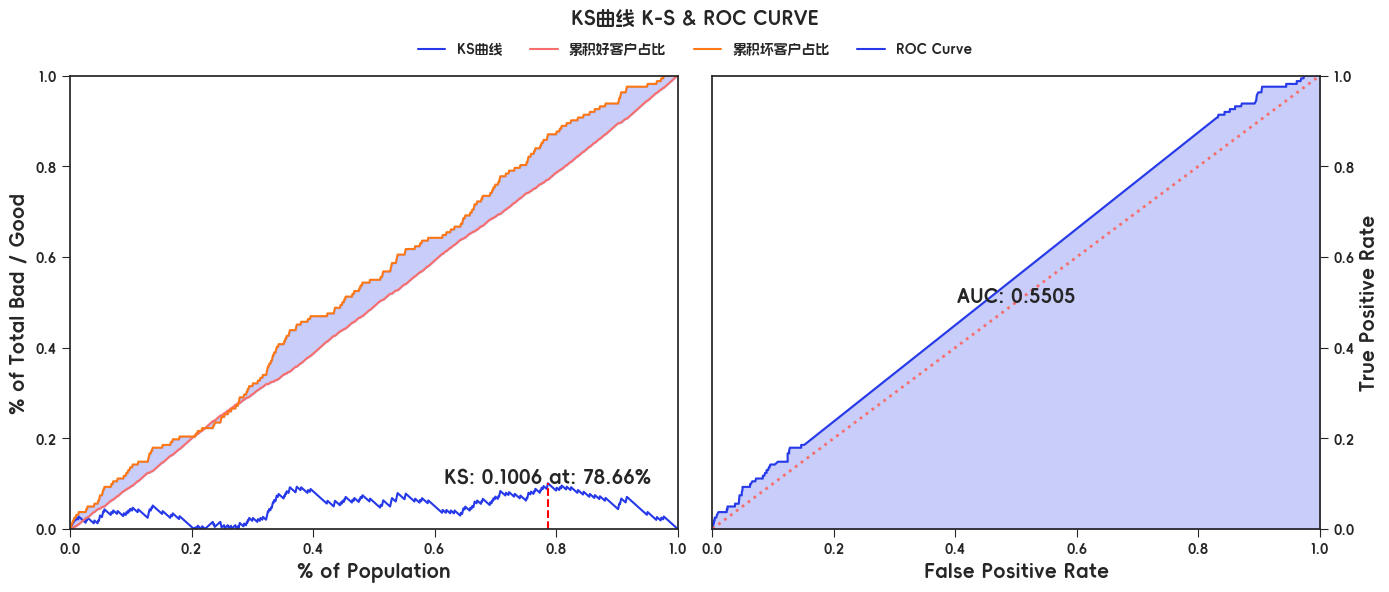

In [4]:
# KS曲线
fig = viz.ks_plot(
    df['prob'],
    df['target'],
    title='KS曲线',
    figsize=(14, 6)
)
plt.show()

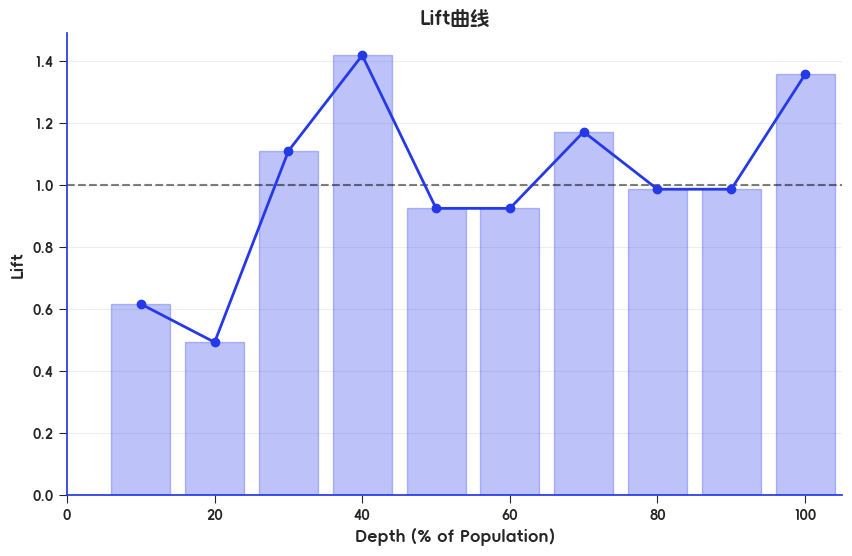

In [5]:
# Lift曲线
fig = viz.lift_plot(
    df['target'],
    df['prob'],
    title='Lift曲线',
    figsize=(10, 6)
)
plt.show()

## 3. 分布图

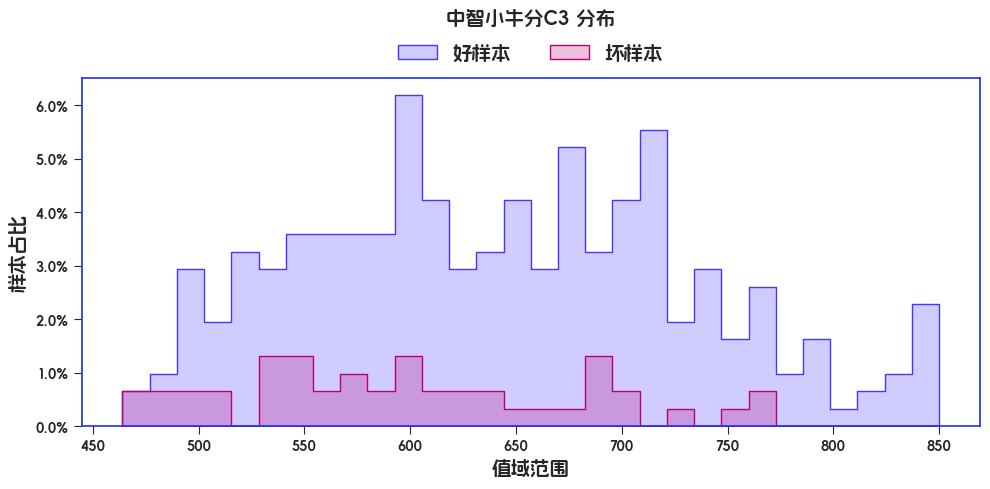

In [11]:
# 特征分布
fig = viz.hist_plot(
    df['中智小牛分C3'],
    y_true=df['target'],
    title='中智小牛分C3 分布',
    figsize=(10, 5),
)
plt.show()

## 4. 相关性热力图

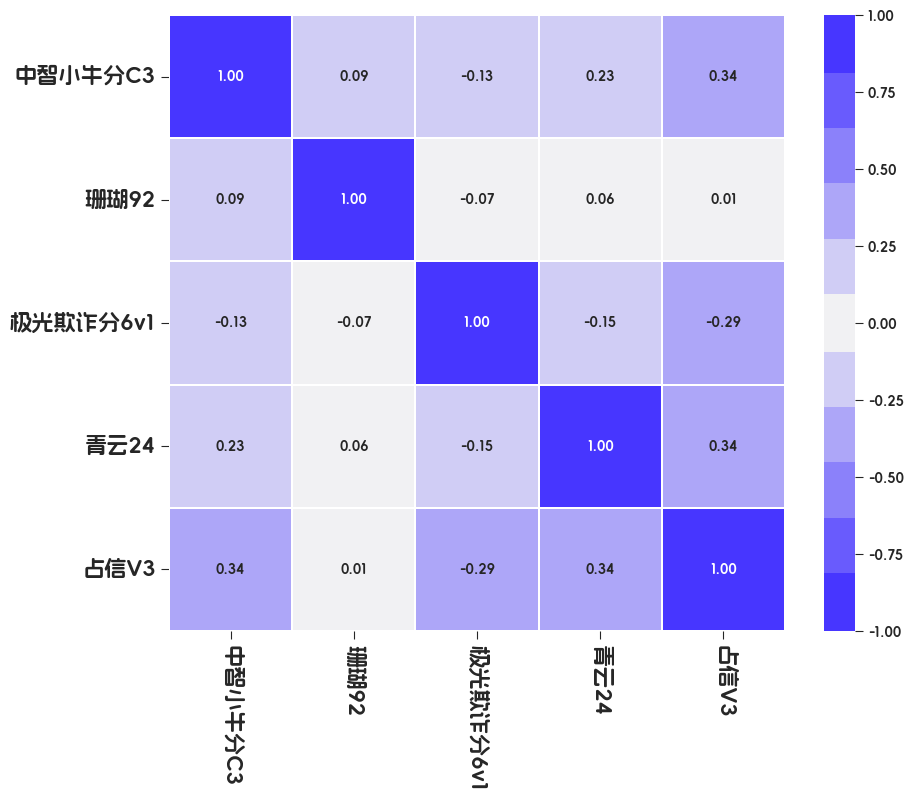

In [7]:
# 相关性热力图
features = ['中智小牛分C3', '珊瑚92', '极光欺诈分6v1', '青云24', '占信V3']
fig = viz.corr_plot(
    df[features],
    # title='特征相关性热力图',
    figsize=(10, 8)
)
plt.show()